In [1]:
# Clone the official dataset repo (skip if already cloned)
import os
if not os.path.exists("semeval2026-task12-dataset"):
    !git clone https://github.com/sooo66/semeval2026-task12-dataset.git
else:
    print("Already cloned.")

Already cloned.


In [2]:
import json
import pandas as pd
from pathlib import Path

ROOT = Path("semeval2026-task12-dataset")
SPLITS = ["train_data", "dev_data", "test_data"]

def load_questions(split):
    return pd.read_json(ROOT / split / "questions.jsonl", lines=True)

def load_docs(split):
    with open(ROOT / split / "docs.json", encoding="utf-8") as f:
        raw = json.load(f)
    return pd.DataFrame(raw)  # one row per topic, with a 'docs' column of lists

questions = {s: load_questions(s) for s in SPLITS}
docs = {s: load_docs(s) for s in SPLITS}

for s in SPLITS:
    print(f"{s:12s} | questions={questions[s].shape} | docs(topics)={docs[s].shape}")

train_data   | questions=(1819, 8) | docs(topics)=(36, 3)
dev_data     | questions=(400, 8) | docs(topics)=(36, 3)
test_data    | questions=(612, 7) | docs(topics)=(24, 3)


In [3]:
unique_topics = {}  # topic_id -> list of docs (deduped across splits)
for s in SPLITS:
    for _, row in docs[s].iterrows():
        unique_topics.setdefault(row["topic_id"], row["docs"])

print(f"Unique topics across all splits: {len(unique_topics)}  (paper reports 60)")

Unique topics across all splits: 60  (paper reports 60)


In [4]:
# --- Question / topic counts per split ---
print("QUESTIONS & TOPICS PER SPLIT")
print("-" * 60)
for s in SPLITS:
    n_q = len(questions[s])
    n_t = questions[s]["topic_id"].nunique()
    print(f"{s:12s} | questions={n_q:5d} | topics={n_t:3d}")

total_q = sum(len(questions[s]) for s in SPLITS)
print(f"\nTotal questions: {total_q}  (paper: 2,831)")
print(f"Total unique topics: {len(unique_topics)}  (paper: 60)")

QUESTIONS & TOPICS PER SPLIT
------------------------------------------------------------
train_data   | questions= 1819 | topics= 36
dev_data     | questions=  400 | topics= 36
test_data    | questions=  612 | topics= 24

Total questions: 2831  (paper: 2,831)
Total unique topics: 60  (paper: 60)


In [5]:
# --- Topic overlap check (data integrity) ---
# Expected: train and dev SHARE all 36 topics (by design).
#           test's 24 topics are disjoint from both.
topic_sets = {s: set(questions[s]["topic_id"]) for s in SPLITS}

td = topic_sets["train_data"] & topic_sets["dev_data"]
tt = topic_sets["train_data"] & topic_sets["test_data"]
dt = topic_sets["dev_data"] & topic_sets["test_data"]

print(f"train ∩ dev  : {len(td)} shared topics  (expected: 36, by design)")
print(f"train ∩ test : {len(tt)} shared topics  (expected: 0)")
print(f"dev ∩ test   : {len(dt)} shared topics  (expected: 0)")

train ∩ dev  : 36 shared topics  (expected: 36, by design)
train ∩ test : 0 shared topics  (expected: 0)
dev ∩ test   : 0 shared topics  (expected: 0)


In [6]:
# --- Avg documents per topic (paper reports 19.7) ---
docs_per_topic = [len(v) for v in unique_topics.values()]
avg_docs_per_topic = sum(docs_per_topic) / len(docs_per_topic)
print(f"Avg docs/topic (deduped, n={len(docs_per_topic)} topics): "
      f"{avg_docs_per_topic:.2f}  (paper: 19.7)")

Avg docs/topic (deduped, n=60 topics): 19.67  (paper: 19.7)


In [7]:
for s in ["train_data", "dev_data"]:
    df = questions[s]
    n_multi = df["golden_answer"].astype(str).str.contains(",").sum()
    print(f"{s:12s}: {100*n_multi/len(df):.1f}% multi-answer  (n={len(df)})")

combined = pd.concat([questions["train_data"], questions["dev_data"]], ignore_index=True)
n_multi_combined = combined["golden_answer"].astype(str).str.contains(",").sum()
print(f"\nCombined train+dev: {100*n_multi_combined/len(combined):.2f}%  (paper: 43.58%)")

# Confirm test has no golden_answer at all (paper says "removed")
print(f"\n'golden_answer' present in test columns: {'golden_answer' in questions['test_data'].columns}")
print(f"(paper / README state this should be False)")

train_data  : 42.7% multi-answer  (n=1819)
dev_data    : 47.5% multi-answer  (n=400)

Combined train+dev: 43.58%  (paper: 43.58%)

'golden_answer' present in test columns: False
(paper / README state this should be False)


In [8]:
combined["num_answers"] = combined["golden_answer"].astype(str).str.split(",").apply(len)
print(combined["num_answers"].value_counts(normalize=True).sort_index() * 100)

num_answers
1    56.421812
2    29.743128
3    13.835061
Name: proportion, dtype: float64


In [9]:
none_text = "None of the others are correct causes"
option_cols = ["option_A", "option_B", "option_C", "option_D"]

has_none = combined[option_cols].apply(
    lambda row: row.astype(str).str.contains(none_text, regex=False).any(), axis=1
)
print(f"Questions where a 'None' option is PRESENT (train+dev): {has_none.mean()*100:.2f}%")

# When None is present, is it always the correct answer, or sometimes a distractor?
def none_is_golden(row):
    golden = [g.strip() for g in str(row["golden_answer"]).split(",")]
    for g in golden:
        col = f"option_{g}"
        if col in option_cols and none_text in str(row[col]):
            return True
    return False

none_and_golden = combined[has_none].apply(none_is_golden, axis=1)
print(f"Of those, 'None' is the correct answer: {none_and_golden.mean()*100:.2f}% of the time")

# Which letter slot does None tend to occupy?
for col in option_cols:
    pct = combined[col].astype(str).str.contains(none_text, regex=False).mean() * 100
    print(f"  {col}: contains 'None' option in {pct:.2f}% of rows")

Questions where a 'None' option is PRESENT (train+dev): 14.60%
Of those, 'None' is the correct answer: 100.00% of the time
  option_A: contains 'None' option in 3.70% of rows
  option_B: contains 'None' option in 3.61% of rows
  option_C: contains 'None' option in 3.83% of rows
  option_D: contains 'None' option in 3.47% of rows


In [10]:
option_cols = ["option_A", "option_B", "option_C", "option_D"]

def get_dupe_letters(row):
    """Return letter-pairs (e.g. ('B','D')) whose option text is identical."""
    opts = {c.split("_")[1]: str(row[c]).strip() for c in option_cols}
    seen, pairs = {}, []
    for letter, text in opts.items():
        if text in seen:
            pairs.append((seen[text], letter))
        else:
            seen[text] = letter
    return pairs

combined["_dupe_pairs"] = combined.apply(get_dupe_letters, axis=1)
has_dupe = combined["_dupe_pairs"].apply(len) > 0
dupe_rows = combined[has_dupe]

print(f"Questions with duplicate option text (train+dev): {has_dupe.mean()*100:.2f}%  (n={has_dupe.sum()})")

def classify(row):
    golden = set(g.strip() for g in str(row["golden_answer"]).split(","))
    statuses = set()
    for (l1, l2) in row["_dupe_pairs"]:
        if l1 in golden and l2 in golden:
            statuses.add("both_golden")
        elif l1 not in golden and l2 not in golden:
            statuses.add("both_distractor")
        else:
            statuses.add("MISMATCH")
    return statuses

classes = dupe_rows.apply(classify, axis=1)
both_golden = classes.apply(lambda s: "both_golden" in s).sum()
both_distractor = classes.apply(lambda s: "both_distractor" in s).sum()
mismatch = classes.apply(lambda s: "MISMATCH" in s).sum()

print(f"  Both duplicate options ARE golden:        {both_golden}  ({100*both_golden/len(dupe_rows):.1f}%)")
print(f"  Both duplicate options are distractors:   {both_distractor}  ({100*both_distractor/len(dupe_rows):.1f}%)")
print(f"  MISMATCH (contradictory -- a real bug):   {mismatch}  ({100*mismatch/len(dupe_rows):.1f}%)")

Questions with duplicate option text (train+dev): 22.94%  (n=509)
  Both duplicate options ARE golden:        509  (100.0%)
  Both duplicate options are distractors:   0  (0.0%)
  MISMATCH (contradictory -- a real bug):   0  (0.0%)


In [11]:
summary = pd.DataFrame([
    ["Total questions",            "2,831",       f"{total_q}"],
    ["Total topics",               "60",          f"{len(unique_topics)}"],
    ["Train/Dev/Test questions",   "1,819/400/612",
        f"{len(questions['train_data'])}/{len(questions['dev_data'])}/{len(questions['test_data'])}"],
    ["Avg docs/topic",             "19.7",        f"{avg_docs_per_topic:.2f}"],
    ["Multi-answer % (train+dev)", "43.58%",      f"{100*n_multi_combined/len(combined):.2f}%"],
    ["'None' option present (train+dev)", "not reported", f"{has_none.mean()*100:.2f}%"],
    ["Duplicate options (train+dev)",     "not reported", f"{has_dupe.mean()*100:.2f}%"],
], columns=["Statistic", "Paper reports", "Reproduced here"])

summary

,Statistic,Paper reports,Reproduced here
0,Total questions,"2,831",2831
1,Total topics,60,60
2,Train/Dev/Test questions,"1,819/400/612",1819/400/612
3,Avg docs/topic,19.7,19.67
4,Multi-answer % (train+dev),43.58%,43.58%
5,'None' option present (train+dev),not reported,14.60%
6,Duplicate options (train+dev),not reported,22.94%


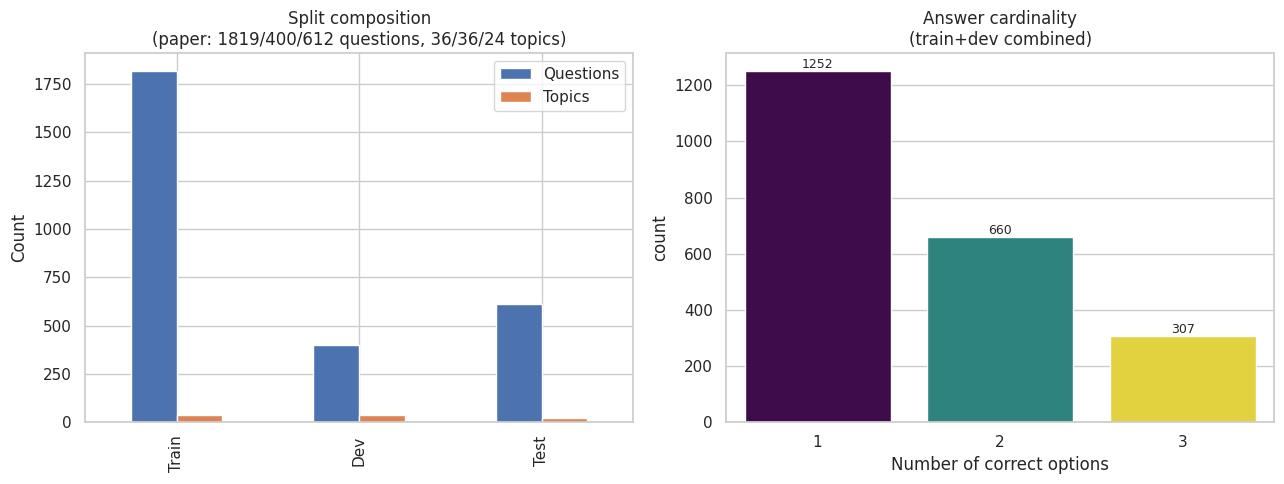

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (A) Split composition
split_counts = pd.DataFrame({
    "Questions": [len(questions[s]) for s in SPLITS],
    "Topics":    [questions[s]["topic_id"].nunique() for s in SPLITS],
}, index=["Train", "Dev", "Test"])
split_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Split composition\n(paper: 1819/400/612 questions, 36/36/24 topics)")
axes[0].set_ylabel("Count")

# (B) Answer cardinality
sns.countplot(data=combined, x="num_answers", hue="num_answers",
              palette="viridis", legend=False, ax=axes[1])
axes[1].set_title("Answer cardinality\n(train+dev combined)")
axes[1].set_xlabel("Number of correct options")
for p in axes[1].patches:
    axes[1].annotate(f"{int(p.get_height())}",
                      (p.get_x() + p.get_width()/2, p.get_height()),
                      ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

rows = []
for _, row in combined.iterrows():
    golden = set(g.strip() for g in str(row["golden_answer"]).split(","))
    for col in option_cols:
        letter = col.split("_")[1]
        rows.append({"text": str(row[col]), "label": 1 if letter in golden else 0})
opt_df = pd.DataFrame(rows)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    opt_df["text"], opt_df["label"], test_size=0.2, random_state=42, stratify=opt_df["label"]
)
vec = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_train = vec.fit_transform(X_train_text)
X_test = vec.transform(X_test_text)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

leakage_acc = accuracy_score(y_test, preds)
majority_baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"Held-out accuracy using ONLY option text (no context at all): {leakage_acc*100:.1f}%")
print(f"Majority-class baseline (always guess the more common label): {majority_baseline*100:.1f}%")
print(f"\nGap: {(leakage_acc - majority_baseline)*100:.1f} percentage points above baseline")

Held-out accuracy using ONLY option text (no context at all): 89.4%
Majority-class baseline (always guess the more common label): 60.6%

Gap: 28.7 percentage points above baseline


In [14]:
import re

def words(text):
    return set(re.findall(r"\w+", str(text).lower()))

def jaccard(a, b):
    union = a | b
    return len(a & b) / len(union) if union else 0.0

overlap_rows = []
for _, row in combined.iterrows():
    target_words = words(row["target_event"])
    golden = set(g.strip() for g in str(row["golden_answer"]).split(","))
    for col in option_cols:
        letter = col.split("_")[1]
        overlap_rows.append({
            "is_golden": letter in golden,
            "jaccard": jaccard(target_words, words(row[col])),
        })

overlap_df = pd.DataFrame(overlap_rows)
overlap_df.groupby("is_golden")["jaccard"].agg(["mean", "median", "std"])

,mean,median,std
is_golden,,,
False,0.06375,0.055556,0.056001
True,0.07718,0.064516,0.066202


In [15]:
topic_q_counts = combined["topic_id"].value_counts().sort_values(ascending=False)
print(topic_q_counts.describe())
print()
top5_share = topic_q_counts.head(5).sum() / topic_q_counts.sum()
print(f"Top 5 topics (of 36) account for {top5_share*100:.1f}% of all train+dev questions")
print(f"Range: {topic_q_counts.min()} to {topic_q_counts.max()} questions per topic")

count     36.000000
mean      61.638889
std       31.174305
min        8.000000
25%       40.250000
50%       54.000000
75%       76.250000
max      132.000000
Name: count, dtype: float64

Top 5 topics (of 36) account for 26.0% of all train+dev questions
Range: 8 to 132 questions per topic


In [16]:
doc_sources = []
for topic_docs in unique_topics.values():
    for doc in topic_docs:
        doc_sources.append(doc.get("source", "UNKNOWN"))

source_counts = pd.Series(doc_sources).value_counts()
print(f"Total documents: {len(doc_sources)}")
print(f"Unique sources: {source_counts.nunique() if False else len(source_counts)}")
print()
print("Top 10 sources:")
print(source_counts.head(10))
print()
top5_share = source_counts.head(5).sum() / source_counts.sum()
print(f"\nTop 5 sources account for {top5_share*100:.1f}% of all documents")

Total documents: 1180
Unique sources: 535

Top 10 sources:
The New York Times     64
CNN                    59
NPR                    56
CNBC                   34
Al Jazeera             32
The Washington Post    28
Los Angeles Times      18
CBS News               18
The Guardian           15
Space                  15
Name: count, dtype: int64


Top 5 sources account for 20.8% of all documents


In [17]:
full_summary = pd.DataFrame([
    ["Total questions",                     "2,831",        f"{total_q}"],
    ["Total topics",                        "60",           f"{len(unique_topics)}"],
    ["Train/Dev/Test questions",            "1,819/400/612",
        f"{len(questions['train_data'])}/{len(questions['dev_data'])}/{len(questions['test_data'])}"],
    ["Avg docs/topic",                      "19.7",         f"{avg_docs_per_topic:.2f}"],
    ["Multi-answer % (train+dev)",          "43.58%",       f"{100*n_multi_combined/len(combined):.2f}%"],
    ["'None' option present (train+dev)",   "not reported", f"{has_none.mean()*100:.2f}%"],
    ["Duplicate options (train+dev)",       "not reported", f"{has_dupe.mean()*100:.2f}%"],
    ["Leakage check (option-only accuracy)","not reported", f"{leakage_acc*100:.1f}% (baseline {majority_baseline*100:.1f}%)"],
    ["Word-overlap (golden vs distractor)", "not reported",
        f"{overlap_df[overlap_df.is_golden].jaccard.mean():.3f} vs {overlap_df[~overlap_df.is_golden].jaccard.mean():.3f}"],
    ["Top-5-topic question share",          "not reported",
        f"{(topic_q_counts.head(5).sum()/topic_q_counts.sum())*100:.1f}%"],
    ["Unique news sources",                 "not reported", f"{len(source_counts)}"],
], columns=["Statistic", "Paper reports", "Reproduced here"])

full_summary

,Statistic,Paper reports,Reproduced here
0,Total questions,"2,831",2831
1,Total topics,60,60
2,Train/Dev/Test questions,"1,819/400/612",1819/400/612
3,Avg docs/topic,19.7,19.67
4,Multi-answer % (train+dev),43.58%,43.58%
5,'None' option present (train+dev),not reported,14.60%
6,Duplicate options (train+dev),not reported,22.94%
7,Leakage check (option-only accuracy),not reported,89.4% (baseline 60.6%)
8,Word-overlap (golden vs distractor),not reported,0.077 vs 0.064
9,Top-5-topic question share,not reported,26.0%
